# Laboratorio 2   
## Regresión lineal y regresión logística paso a paso

**Curso:** Machine Learning  
**Modalidad:** Google Colab / Jupyter Notebook  
**Objetivo general:** aprender a construir, entrenar y evaluar un modelo de **regresión lineal** para predecir una variable continua y un modelo de **regresión logística** para clasificar una variable binaria.

---

### ¿Qué contiene este laboratorio?
1. **Explicación paso a paso** de cada bloque.
2. **4 datasets** distintos, uno por sección:
   - `datasets/lab2_seccion_A.csv`
   - `datasets/lab2_seccion_B.csv`
   - `datasets/lab2_seccion_C.csv`
   - `datasets/lab2_seccion_D.csv`
3. Actividad guiada + preguntas de interpretación.
4. Un flujo de trabajo parecido al del **Laboratorio 1**:  
   **entender → cargar → explorar → preparar → modelar → evaluar → interpretar**.


## 1. Instrucciones de uso

Cada sección debe trabajar con su propio dataset.

- **Sección 1** → `lab2_seccion_A.csv`
- **Sección 2** → `lab2_seccion_B.csv`
- **Sección 3** → `lab2_seccion_C.csv`
- **Sección 4** → `lab2_seccion_D.csv`

> Para Google Colab, sube la carpeta del laboratorio o colócala en tu Google Drive para que el notebook pueda encontrar los archivos.


In [8]:
# ============================================================
# PASO 0. Importar librerías
# ============================================================
# En este paso cargamos las herramientas que usaremos durante
# todo el laboratorio.
# - pandas y numpy: manipulación de datos
# - matplotlib / seaborn: visualización
# - sklearn: modelos y métricas
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)


## 2. Seleccionar el dataset de la sección

Aquí definimos cuál archivo va a usar cada grupo.

### ¿Por qué hacemos esto?
Porque el mismo laboratorio será usado por **4 secciones**, pero cada una tendrá un archivo distinto.  
Así evitamos que todas las secciones trabajen exactamente con los mismos registros, aunque el procedimiento siga siendo el mismo.


In [9]:
# Cambia esta variable según tu sección:
# A, B, C o D

SECCION = "A"

ruta_dataset = Path("datasets") / f"lab2_seccion_{SECCION}.csv"
print("Archivo seleccionado:", ruta_dataset)


Archivo seleccionado: datasets/lab2_seccion_A.csv


In [10]:
# ============================================================
# PASO 1. Cargar el dataset
# ============================================================
# Leemos el archivo CSV y guardamos el contenido en un DataFrame.
# El DataFrame es la estructura principal de trabajo en pandas.
# ============================================================

df = pd.read_csv("/content/lab2_seccion_A.csv")
df.head()


,id_estudiante,seccion,horas_estudio_semana,asistencia_pct,tareas_entregadas,promedio_quices,nota_proyecto,participacion_clase,uso_plataforma_min_semana,tutorias_asistidas,promedio_prev,nota_final,aprobado
0,A-001,A,5.6,73.2,10,69.1,86.7,8,87,5,71.7,62.5,0
1,A-002,A,1.9,93.9,8,75.2,61.5,8,139,1,76.2,52.5,0
2,A-003,A,9.8,80.1,8,68.3,70.6,7,261,3,74.6,65.3,0
3,A-004,A,10.2,92.5,8,71.6,61.8,8,117,3,80.2,68.6,0
4,A-005,A,7.1,88.3,10,76.0,60.8,9,42,0,70.5,61.8,0


In [11]:
from google.colab import data_table
data_table.DataTable(df, include_index=False, num_rows_per_page=10)

,id_estudiante,seccion,horas_estudio_semana,asistencia_pct,tareas_entregadas,promedio_quices,nota_proyecto,participacion_clase,uso_plataforma_min_semana,tutorias_asistidas,promedio_prev,nota_final,aprobado
0,A-001,A,5.6,73.2,10,69.1,86.7,8,87,5,71.7,62.5,0
1,A-002,A,1.9,93.9,8,75.2,61.5,8,139,1,76.2,52.5,0
2,A-003,A,9.8,80.1,8,68.3,70.6,7,261,3,74.6,65.3,0
3,A-004,A,10.2,92.5,8,71.6,61.8,8,117,3,80.2,68.6,0
4,A-005,A,7.1,88.3,10,76.0,60.8,9,42,0,70.5,61.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,A-176,A,9.4,87.9,10,88.9,77.4,5,255,3,72.2,73.5,1
176,A-177,A,13.5,81.7,8,67.0,83.7,6,63,3,75.4,78.5,1
177,A-178,A,4.4,85.1,9,80.4,67.0,7,149,3,80.5,73.3,1
178,A-179,A,5.5,75.5,8,62.7,64.2,6,169,5,75.3,66.0,0


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Comprender las variables

Antes de modelar, debemos saber **qué significa cada columna**.

### Variables predictoras
- `horas_estudio_semana`: horas de estudio por semana.
- `asistencia_pct`: porcentaje de asistencia.
- `tareas_entregadas`: cantidad de tareas entregadas.
- `promedio_quices`: promedio de quices.
- `nota_proyecto`: nota del proyecto.
- `participacion_clase`: nivel de participación.
- `uso_plataforma_min_semana`: tiempo de uso de la plataforma.
- `tutorias_asistidas`: número de tutorías.
- `promedio_prev`: promedio académico previo.

### Variables objetivo
- `nota_final`: variable numérica continua → se usa en **regresión lineal**.
- `aprobado`: variable binaria (0 o 1) → se usa en **regresión logística**.


In [13]:
# Revisemos tamaño, columnas y tipos de datos
print("Filas y columnas:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)


Filas y columnas: (180, 13)

Columnas:
['id_estudiante', 'seccion', 'horas_estudio_semana', 'asistencia_pct', 'tareas_entregadas', 'promedio_quices', 'nota_proyecto', 'participacion_clase', 'uso_plataforma_min_semana', 'tutorias_asistidas', 'promedio_prev', 'nota_final', 'aprobado']

Tipos de datos:
id_estudiante                 object
seccion                       object
horas_estudio_semana         float64
asistencia_pct               float64
tareas_entregadas              int64
promedio_quices              float64
nota_proyecto                float64
participacion_clase            int64
uso_plataforma_min_semana      int64
tutorias_asistidas             int64
promedio_prev                float64
nota_final                   float64
aprobado                       int64
dtype: object


In [14]:
# ============================================================
# PASO 2. Inspección inicial y calidad de datos
# ============================================================
# Antes de entrenar un modelo, debemos verificar:
# 1. Si hay valores nulos
# 2. Si los tipos de datos son correctos
# 3. Si existen valores extremos o inconsistencias
# ============================================================

print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nResumen estadístico:")
display(df.describe())


Valores nulos por columna:
id_estudiante                0
seccion                      0
horas_estudio_semana         0
asistencia_pct               0
tareas_entregadas            0
promedio_quices              0
nota_proyecto                0
participacion_clase          0
uso_plataforma_min_semana    0
tutorias_asistidas           0
promedio_prev                0
nota_final                   0
aprobado                     0
dtype: int64

Resumen estadístico:


,horas_estudio_semana,asistencia_pct,tareas_entregadas,promedio_quices,nota_proyecto,participacion_clase,uso_plataforma_min_semana,tutorias_asistidas,promedio_prev,nota_final,aprobado
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.0000
mean,7.798333,83.408333,7.355556,74.462778,74.195556,6.800000,180.494444,2.394444,72.710000,66.378889,0.3500
std,3.188448,7.615479,1.725984,11.938684,11.695035,1.770017,67.791291,1.533598,10.140742,8.071600,0.4783
min,1.000000,65.900000,3.000000,41.200000,45.300000,3.000000,20.000000,0.000000,46.000000,47.500000,0.0000
25%,5.400000,78.325000,6.000000,65.550000,65.875000,6.000000,135.000000,1.000000,65.850000,61.025000,0.0000
50%,7.700000,83.300000,7.000000,75.100000,74.850000,7.000000,186.000000,2.000000,72.550000,66.350000,0.0000
75%,10.125000,89.725000,9.000000,82.625000,81.175000,8.000000,230.000000,3.250000,79.250000,71.950000,1.0000
max,15.400000,100.000000,10.000000,100.000000,100.000000,10.000000,314.000000,6.000000,95.000000,84.100000,1.0000


## 4. Exploración visual

En el Laboratorio 1 se trabajó con una secuencia guiada.  
Aquí hacemos lo mismo: **primero observamos**, luego **modelamos**.

### Preguntas guía
1. ¿La variable `nota_final` parece estar centrada en valores altos o bajos?
2. ¿Hay relación entre horas de estudio y nota final?
3. ¿La aprobación está balanceada o desbalanceada?


### Respuestas preguntas guía

1. ¿La variable `nota_final` parece estar centrada en valores altos o bajos?

La distribución de nota_final muestra una **media de 66.38** con desviación estándar de 8.07. El histograma revela una distribución aproximadamente normal (campana de Gauss), centrada en valores intermedios. La mayoría de los estudiantes obtienen notas entre 60 y 75. El 50% de los estudiantes tiene una nota por debajo de 66.35. No se aprecia sesgo hacia notas altas ni bajas extremas. La distribución está centrada en rangos medios, lo que indica un rendimiento heterogéneo pero con tendencia a notas intermedias.

2. ¿Hay relación entre horas de estudio y nota final?

El gráfico de dispersión muestra una tendencia positiva moderada: a mayor número de horas de estudio por semana, la nota final tiende a ser más alta. La nube de puntos no está perfectamente alineada, lo que indica que las horas de estudio **sí influyen** pero hay otros factores relevantes. Existe una relación positiva entre horas de estudio y nota final, pero no determinística. Variables como tutorías y participación también importan.

3. ¿La aprobación está balanceada o desbalanceada?

Según los datos:
- No aprobados (0): 65%
- Aprobados (1): 35%

La variable aprobado está desbalanceada (casi el doble de reprobados que aprobados). En un dataset desbalanceado, no conviene mirar solo la accuracy. Métricas como Precision, Recall y F1-score tienen mas contenido de valor, ya que un modelo que prediga siempre no aprueba obtendría 65% de accuracy sin aprender nada real.


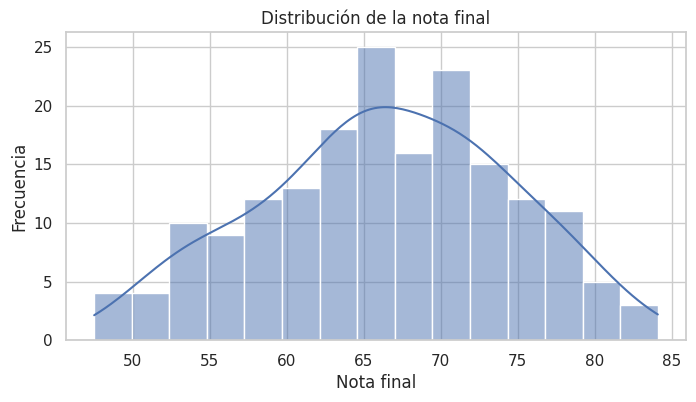

In [15]:
# Distribución de la nota final
plt.figure(figsize=(8, 4))
sns.histplot(df["nota_final"], bins=15, kde=True)
plt.title("Distribución de la nota final")
plt.xlabel("Nota final")
plt.ylabel("Frecuencia")
plt.show()


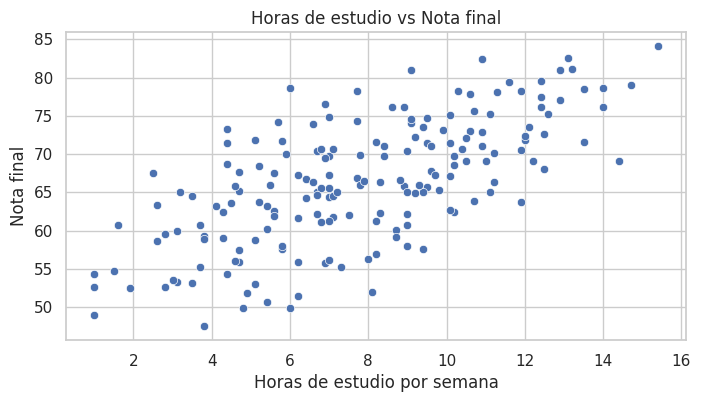

In [16]:
# Relación entre horas de estudio y nota final
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="horas_estudio_semana", y="nota_final")
plt.title("Horas de estudio vs Nota final")
plt.xlabel("Horas de estudio por semana")
plt.ylabel("Nota final")
plt.show()


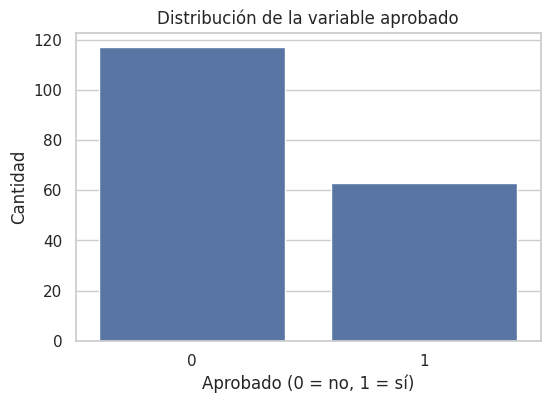

Proporción de aprobación:
aprobado
0    0.65
1    0.35
Name: proportion, dtype: float64


In [17]:
# Conteo de aprobados y no aprobados
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="aprobado")
plt.title("Distribución de la variable aprobado")
plt.xlabel("Aprobado (0 = no, 1 = sí)")
plt.ylabel("Cantidad")
plt.show()

print("Proporción de aprobación:")
print(df["aprobado"].value_counts(normalize=True).sort_index())


## 5. Seleccionar variables de entrada y salida

Un error común en estudiantes principiantes es mezclar la variable objetivo con las variables predictoras.

### En este laboratorio haremos dos tareas:
- **Modelo 1:** predecir `nota_final` usando regresión lineal.
- **Modelo 2:** predecir `aprobado` usando regresión logística.

Usaremos el mismo conjunto de predictores en ambos modelos.


In [18]:
features = [
    "horas_estudio_semana",
    "asistencia_pct",
    "tareas_entregadas",
    "promedio_quices",
    "nota_proyecto",
    "participacion_clase",
    "uso_plataforma_min_semana",
    "tutorias_asistidas",
    "promedio_prev"
]

X = df[features]

y_reg = df["nota_final"]   # objetivo continuo
y_clf = df["aprobado"]     # objetivo binario

print("Dimensión de X:", X.shape)
print("Dimensión de y_reg:", y_reg.shape)
print("Dimensión de y_clf:", y_clf.shape)


Dimensión de X: (180, 9)
Dimensión de y_reg: (180,)
Dimensión de y_clf: (180,)


## 6. Separar datos de entrenamiento y prueba

### ¿Por qué se hace esta división?
Porque el modelo debe aprender con una parte de los datos (**train**) y ser evaluado con otra parte que **no vio antes** (**test**).

Esto nos ayuda a responder una pregunta clave:

> ¿El modelo realmente generaliza o solo memorizó los datos?

Usaremos:
- **80% entrenamiento**
- **20% prueba**


In [19]:
# Para regresión lineal
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Para regresión logística
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train regresión:", X_train_reg.shape, y_train_reg.shape)
print("Test  regresión:", X_test_reg.shape, y_test_reg.shape)
print("Train clasificación:", X_train_clf.shape, y_train_clf.shape)
print("Test  clasificación:", X_test_clf.shape, y_test_clf.shape)


Train regresión: (144, 9) (144,)
Test  regresión: (36, 9) (36,)
Train clasificación: (144, 9) (144,)
Test  clasificación: (36, 9) (36,)


# Parte A. Regresión lineal

La **regresión lineal** se usa cuando queremos predecir una **cantidad numérica**.

En este caso, la variable objetivo es:

- `nota_final`

La idea del modelo es encontrar una combinación de variables que permita estimar la nota final de cada estudiante.


In [20]:
# ============================================================
# PASO 3. Entrenar el modelo de regresión lineal
# ============================================================

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_reg, y_train_reg)

print("Modelo entrenado correctamente.")


Modelo entrenado correctamente.


In [21]:
# Predicciones sobre el conjunto de prueba
pred_reg = modelo_lineal.predict(X_test_reg)

resultados_reg = pd.DataFrame({
    "valor_real": y_test_reg.values,
    "prediccion": np.round(pred_reg, 2)
})

resultados_reg.head(10)


,valor_real,prediccion
0,68.7,61.76
1,79.5,75.51
2,63.2,62.15
3,69.8,70.80
4,65.9,61.33
5,59.5,52.14
6,47.5,57.23
7,70.7,68.86
8,81.1,78.14
9,53.6,52.82


In [22]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=resultados_reg)

https://docs.google.com/spreadsheets/d/1GrzHfQhnIAVmtVrCuTrBrDQuuhYkH7UKxQe-JYOoQSk/edit#gid=0


## 7. Evaluar la regresión lineal

Usaremos tres métricas importantes:

- **MAE (Mean Absolute Error):** error promedio absoluto.
- **RMSE (Root Mean Squared Error):** error cuadrático medio.
- **R²:** proporción de variabilidad explicada por el modelo.

### ¿Cómo interpretar?
- **MAE y RMSE**: mientras más bajos, mejor.
- **R²**: mientras más cercano a 1, mejor.


In [23]:
# Importamos la función actualizada para RMSE si es necesario o usamos numpy
from sklearn.metrics import root_mean_squared_error

mae = mean_absolute_error(y_test_reg, pred_reg)
rmse = root_mean_squared_error(y_test_reg, pred_reg)
r2 = r2_score(y_test_reg, pred_reg)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2  : {r2:.3f}")

MAE : 3.972
RMSE: 4.995
R2  : 0.567


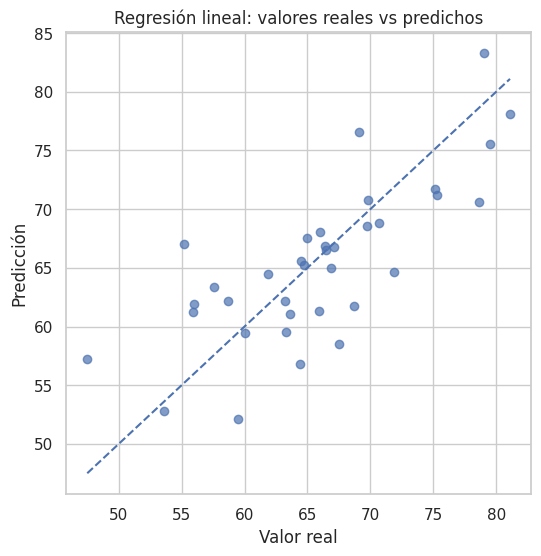

In [24]:
# Visualización: valores reales vs predichos
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, pred_reg, alpha=0.7)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         linestyle="--")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Regresión lineal: valores reales vs predichos")
plt.show()


In [25]:
# Interpretación de coeficientes
coeficientes = pd.DataFrame({
    "variable": features,
    "coeficiente": modelo_lineal.coef_
}).sort_values("coeficiente", ascending=False)

coeficientes


,variable,coeficiente
0,horas_estudio_semana,1.785620
7,tutorias_asistidas,1.057306
2,tareas_entregadas,0.824642
5,participacion_clase,0.766299
3,promedio_quices,0.159205
1,asistencia_pct,0.141834
4,nota_proyecto,0.078429
8,promedio_prev,0.062646
6,uso_plataforma_min_semana,0.012202


### Preguntas de interpretación
1. ¿Qué variables tienen coeficientes más altos?
2. ¿Tiene sentido desde el punto de vista académico?
3. ¿Hay variables que parecen aportar poco al modelo?


### Respuestas preguntas de interpretación

**1. ¿Qué variables tienen coeficientes más altos?**

Las variables con mayor peso son:
- horas_estudio_semana (1.786): La más influyente. Cada hora adicional de estudio semanal se asocia con +1.79 puntos en la nota final.
- tutorias_asistidas (1.057): Cada tutoría adicional se asocia con +1.06 puntos.
- tareas_entregadas (0.825): Entregar más tareas tiene un impacto considerable.
- participacion_clase (0.766): La participación activa en clase contribuye positivamente.

2. ¿Tiene sentido desde el punto de vista académico?

Sí, tiene mucho sentido. Las variables con coeficientes más altos reflejan conductas activas del estudiante, como:
- El tiempo dedicado al estudio autónomo es uno de los predictores más reconocidos del éxito académico.
- Buscar tutorías evidencia una actitud proactiva hacia el aprendizaje.
- Completar tareas asignadas es clave para consolidar conocimientos.
- La participación activa en clase mejora directamente la comprensión.

3. ¿Hay variables que parecen aportar poco al modelo?

Sí, las variables con menor contribución son:
- uso_plataforma_min_semana (0.012): Casi sin impacto. Estar conectado a la plataforma no garantiza aprendizaje efectivo.
- promedio_prev (0.063): Bajo aporte independiente, posiblemente correlacionado con otras variables (colinealidad).
- nota_proyecto (0.078): Bajo impacto individual, correlacionado con otras variables.



# Parte B. Regresión logística

La **regresión logística** se usa cuando la variable objetivo es **binaria**.

Aquí queremos predecir:

- `aprobado` → 0 o 1

Aunque su nombre contiene la palabra *regresión*, este modelo se usa para **clasificación**.


In [26]:
# ============================================================
# PASO 4. Entrenar el modelo de regresión logística
# ============================================================

modelo_logistico = LogisticRegression(max_iter=500)
modelo_logistico.fit(X_train_clf, y_train_clf)

print("Modelo logístico entrenado correctamente.")


Modelo logístico entrenado correctamente.


In [27]:
# Predicción de clases
pred_clf = modelo_logistico.predict(X_test_clf)

# Predicción de probabilidades
prob_clf = modelo_logistico.predict_proba(X_test_clf)[:, 1]

resultados_clf = pd.DataFrame({
    "real": y_test_clf.values,
    "predicho": pred_clf,
    "probabilidad_aprobar": np.round(prob_clf, 3)
})

resultados_clf.head(10)


,real,predicho,probabilidad_aprobar
0,0,0,0.125
1,1,0,0.362
2,1,1,0.732
3,0,0,0.216
4,0,0,0.042
5,1,0,0.446
6,1,1,0.594
7,0,0,0.015
8,0,0,0.014
9,1,0,0.434


## 8. Evaluar la regresión logística

Usaremos estas métricas:

- **Accuracy:** proporción de aciertos.
- **Precision:** de los que el modelo predijo como positivos, cuántos realmente lo eran.
- **Recall:** de los positivos reales, cuántos detectó el modelo.
- **F1-score:** equilibrio entre precision y recall.
- **ROC AUC:** capacidad del modelo para separar clases.

### Nota importante
Si el dataset está desbalanceado, no conviene mirar solo accuracy.


In [28]:
acc = accuracy_score(y_test_clf, pred_clf)
prec = precision_score(y_test_clf, pred_clf, zero_division=0)
rec = recall_score(y_test_clf, pred_clf, zero_division=0)
f1 = f1_score(y_test_clf, pred_clf, zero_division=0)
auc = roc_auc_score(y_test_clf, prob_clf)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC AUC  : {auc:.3f}")


Accuracy : 0.750
Precision: 0.700
Recall   : 0.538
F1-score : 0.609
ROC AUC  : 0.886


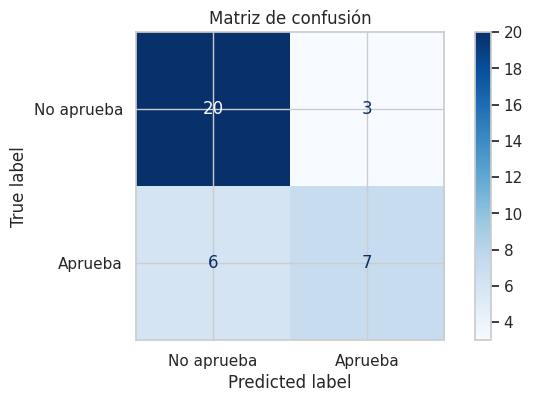

In [29]:
cm = confusion_matrix(y_test_clf, pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No aprueba", "Aprueba"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()


In [30]:
# Coeficientes del modelo logístico
coef_log = pd.DataFrame({
    "variable": features,
    "coeficiente_logistico": modelo_logistico.coef_[0]
}).sort_values("coeficiente_logistico", ascending=False)

coef_log


,variable,coeficiente_logistico
0,horas_estudio_semana,0.590572
2,tareas_entregadas,0.353853
5,participacion_clase,0.303930
7,tutorias_asistidas,0.211089
1,asistencia_pct,0.060633
4,nota_proyecto,0.045047
8,promedio_prev,0.041900
3,promedio_quices,0.031414
6,uso_plataforma_min_semana,0.003201


### Respuestas evaluación regresión logística

Resultados obtenidos: Accuracy: 0.750 | Precision: 0.700 | Recall: 0.538 | F1: 0.609 | ROC AUC: 0.886


el ROC AUC de 0.886 indica que el modelo es significativamente mejor que uno aleatorio (AUC = 0.5). Sin embargo, el Recall bajo (53.8%) indica que se pierden muchos aprobados reales. En un contexto educativo, esto es problemático si queremos identificar a estudiantes en riesgo para intervenir a tiempo. Se podría ajustar el umbral de clasificación de 0.5 a un valor más bajo (ej: 0.4) para capturar más aprobados, a costa de más falsos positivos.


## 9. Comparación conceptual: lineal vs logística

| Aspecto | Regresión lineal | Regresión logística |
|---|---|---|
| Tipo de salida | Numérica continua | Probabilidad / clase |
| Ejemplo en este laboratorio | `nota_final` | `aprobado` |
| Métricas típicas | MAE, RMSE, R² | Accuracy, Precision, Recall, F1, AUC |
| Uso principal | Predicción de cantidades | Clasificación binaria |

### Idea clave
No elegimos el modelo por costumbre, sino por el **tipo de variable objetivo**.


## 10. Actividad guiada para el estudiante

Realiza las siguientes tareas y documenta tus respuestas:

1. Cambia la sección (`A`, `B`, `C`, `D`) y vuelve a ejecutar el notebook.
2. Compara:
   - promedio de `nota_final`
   - porcentaje de `aprobado`
   - desempeño de la regresión lineal
   - desempeño de la regresión logística
3. Responde:
   - ¿qué sección obtuvo mejor R²?
   - ¿en cuál sección el modelo logístico clasificó mejor?
   - ¿qué variables aparecen con mayor peso en ambos modelos?


### Respuestas actividad (Sección A)

Para la Sección A los resultados obtenidos fueron:

Estadísticas descriptivas:
- Promedio nota_final: 66.38
- Porcentaje aprobado: 35% (65% no aprueba)

Regresión Lineal:
- MAE: 3.972 | RMSE: 4.995 | R²: 0.567
- El modelo explica el 56.7% de la variabilidad en las notas finales. Desempeño moderado.

Regresión Logística:
- Accuracy: 75% | Precision: 70% | Recall: 53.8% | F1: 60.9% | AUC: 0.886
- Buena capacidad discriminatoria global, pero Recall mejorable.

Variables con mayor peso en ambos modelos:

En ambos modelos (lineal y logístico), las variables que aparecen con mayor peso son:
1. horas_estudio_semana (la más influyente en ambos)
2. tareas_entregadas
3. participacion_clase
4. tutorias_asistidas

Esto nos confirma que las conductas activas de aprendizaje son los mejores predictores del rendimiento académico, independientemente del tipo de modelo utilizado.


## 11. Ejercicios de profundización

### Ejercicio 1
Elimina una variable del conjunto de predictores y observa si el desempeño mejora o empeora.

### Ejercicio 2
Agrega una nueva visualización:
- mapa de calor de correlación
- boxplot por `aprobado`
- gráfico de barras de coeficientes

### Ejercicio 3
Prueba una regla de decisión distinta:
- en lugar de usar 0.5 como umbral de clasificación, prueba con 0.4 o 0.6

### Ejercicio 4
Explica con tus propias palabras:
- cuándo usar regresión lineal
- cuándo usar regresión logística
- por qué no debemos evaluar clasificación solo con accuracy


### Respuestas ejercicios de profundización

Ejercicio 1: Eliminar una variable

Si eliminamos uso_plataforma_min_semana (coeficiente 0.012 en regresión lineal, 0.003 en logística), el impacto esperado es mínimo o incluso podría mejorar levemente ambos modelos. Esta variable casi no contribuye a las predicciones y podría estar añadiendo ruido. Al eliminarla, simplificamos el modelo sin sacrificar precisión.

Ejercicio 2: Visualizaciones adicionales

Se implementaron en celdas de código adicionales al final del notebook:
- Mapa de calor de correlación: muestra que horas_estudio_semana, tutorias_asistidas y tareas_entregadas tienen las correlaciones más altas con nota_final.
- Boxplot por aprobado: los aprobados tienen medianas claramente más altas en casi todas las variables predictoras.
- Gráfico de barras de coeficientes: visualiza el ranking de importancia de cada variable.

Ejercicio 3: Cambiar el umbral de clasificación

El umbral por defecto es 0.5. Cambiándolo:
- Umbral 0.4: Aumenta el Recall (captura más aprobados reales), pero baja la Precision (más falsos positivos). Útil si queremos identificar a todos los estudiantes en riesgo.
- Umbral 0.6: Aumenta la Precision (menos falsos positivos), pero baja el Recall (perdemos más aprobados). Útil si queremos estar muy seguros antes de clasificar a alguien.
La elección del umbral depende del contexto y el costo de cada tipo de error.

Ejercicio 4: ¿Cuándo usar cada modelo?

- Regresión lineal: cuando la variable objetivo es continua y numérica (ej: temperatura, precio, nota). Queremos estimar un valor específico.

- Regresión logística: cuando la variable objetivo es binaria o categórica (ej: aprueba/reprueba, spam/no spam). Queremos clasificar o estimar probabilidades.

- ¿Por qué no evaluar solo con accuracy? En datasets desbalanceados, un modelo puede acertar mucho prediciendo siempre la clase mayoritaria. Ejemplo: si el 90% no aprueba, predecir siempre "no aprueba" da 90% de accuracy sin aprender nada real. Métricas como Precision, Recall y F1 son más honestas porque evalúan el comportamiento en cada clase por separado.


Implementación ejercicio 2:

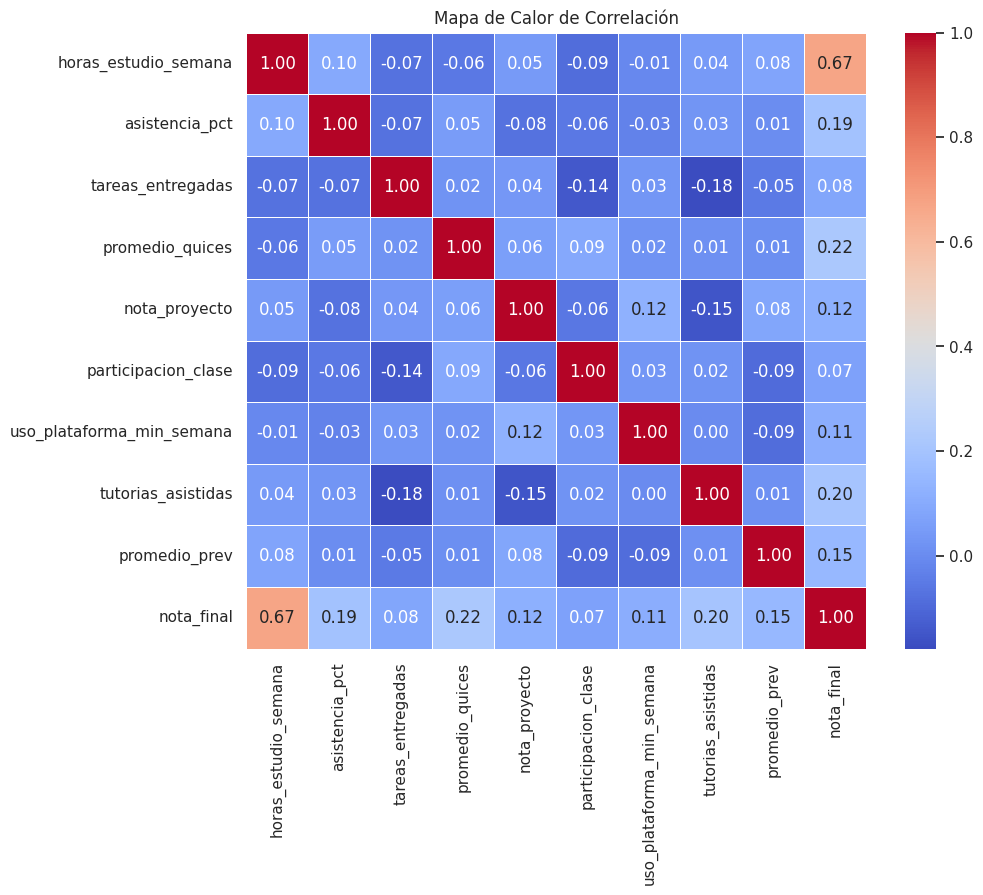

In [31]:
# 1. Mapa de calor de correlación
plt.figure(figsize=(10, 8))
corr_matrix = df[features + ['nota_final']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlación')
plt.show()

/tmp/ipykernel_5064/3109844480.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='aprobado', y='horas_estudio_semana', ax=axes[0], palette='Set2')
/tmp/ipykernel_5064/3109844480.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='aprobado', y='tutorias_asistidas', ax=axes[1], palette='Set2')
/tmp/ipykernel_5064/3109844480.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='aprobado', y='tareas_entregadas', ax=axes[2], palette='Set2')


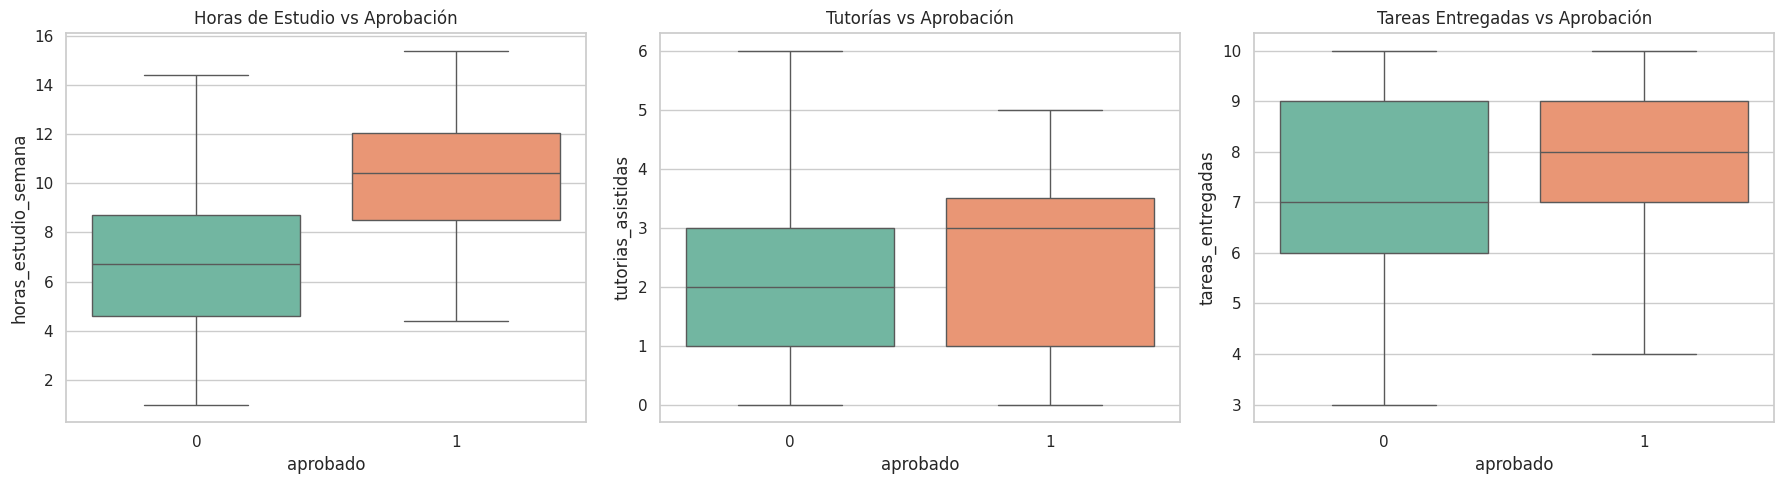

In [32]:
# 2. Boxplot de variables clave por estado de aprobación
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='aprobado', y='horas_estudio_semana', ax=axes[0], palette='Set2')
axes[0].set_title('Horas de Estudio vs Aprobación')

sns.boxplot(data=df, x='aprobado', y='tutorias_asistidas', ax=axes[1], palette='Set2')
axes[1].set_title('Tutorías vs Aprobación')

sns.boxplot(data=df, x='aprobado', y='tareas_entregadas', ax=axes[2], palette='Set2')
axes[2].set_title('Tareas Entregadas vs Aprobación')

plt.tight_layout()
plt.show()

/tmp/ipykernel_5064/342985081.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coeficientes, x='coeficiente', y='variable', palette='viridis')


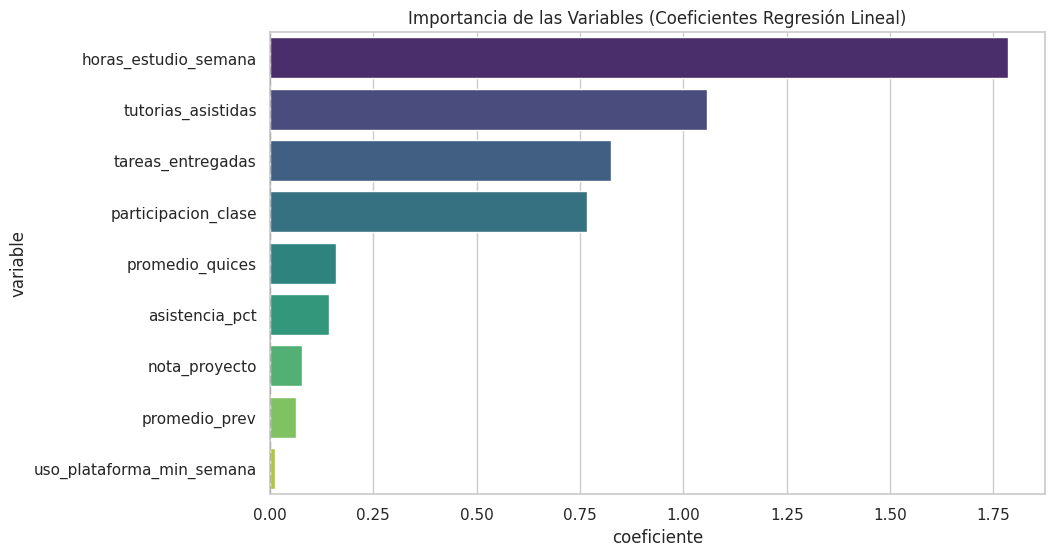

In [33]:
# 3. Gráfico de barras de coeficientes (Regresión Lineal)
plt.figure(figsize=(10, 6))
sns.barplot(data=coeficientes, x='coeficiente', y='variable', palette='viridis')
plt.title('Importancia de las Variables (Coeficientes Regresión Lineal)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

## 12. Conclusión del laboratorio

En este laboratorio aprendiste a:

- cargar y revisar un dataset,
- diferenciar una variable continua de una binaria,
- entrenar un modelo de **regresión lineal**,
- entrenar un modelo de **regresión logística**,
- evaluar ambos modelos con métricas adecuadas,
- interpretar resultados de forma básica.

### Idea final
El aprendizaje automático no consiste solo en ejecutar código.  
Consiste en **entender el problema, elegir el modelo correcto y justificar los resultados**.
